In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import xarray as xr
import xcdat as xc
import numpy as np
import os
from cartopy.util import add_cyclic_point
from matplotlib.ticker import MultipleLocator 

/global/homes/j/jungchoi/.conda/envs/pcmdi_metrics/lib/python3.10/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [3]:

output_dir = "/pscratch/sd/j/jungchoi/DCPP/_metrics"
output_grid_no = "144x72"
figout_dir = "/global/cfs/projectdirs/m4581/jungchoi/PMP/GMD2026/Fig5/_subplots"

# 'coeffi' modifies the unit of the denominator. e.g. coeffi=10, Trend is [unit per 10 years]. 
#var_name = "tas"
#coeffi = 10
var_name = "pr"
coeffi = 100

#model_list =  ['CanESM5', 'CMCC-CM2-SR5', 'CNRM-ESM2-1', 'EC-Earth3', 'FGOALS-f3-L', 'HadGEM3-GC31-MM', 'IPSL-CM6A-LR', 'MIROC6', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorCPM1']
#lead_yr_list = ['HIST', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
## for Fig.3
model_list =  ['MRI-ESM2-0']
lead_yr_list = ['1']

#Read observed trend
obs_file = f"{output_dir}/OBS/{var_name}.{output_grid_no}.mon_trend1979-2014.nc"   
obs_ds = xr.open_dataset(obs_file)
obs_ds.close()


=== MODEL, FILE: MRI-ESM2-0 1 /pscratch/sd/j/jungchoi/DCPP/_metrics/MRI-ESM2-0/pr.144x72.YR1.mon_trend1979-2014.em.nc


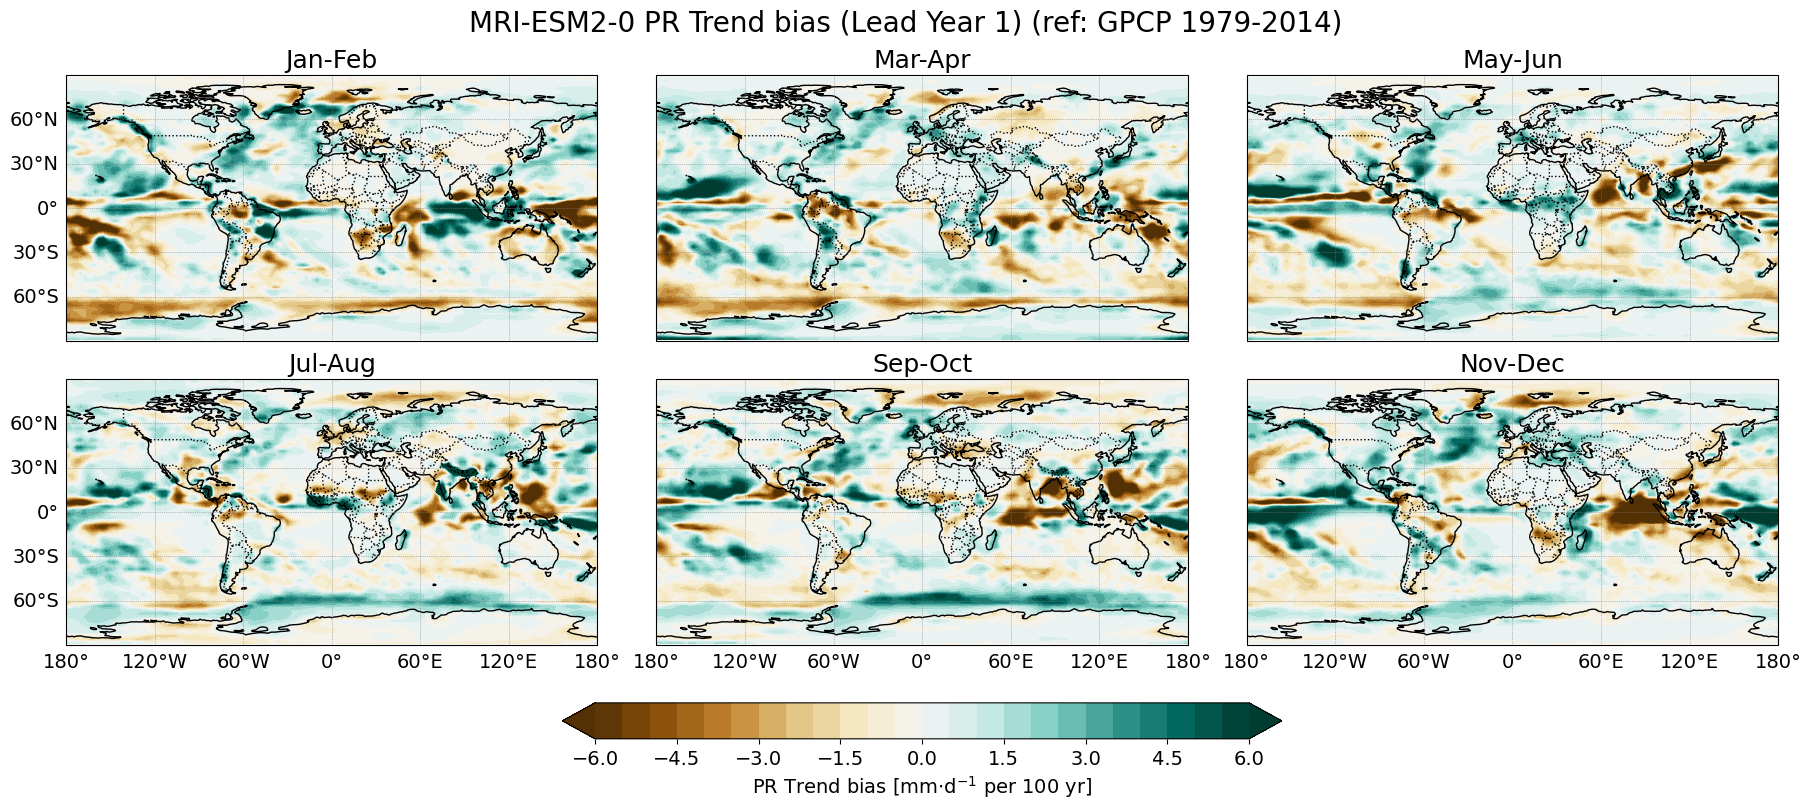

***DONE***


In [4]:

for model in model_list:
    
    end_lead = len(lead_yr_list) + 1
    if model in ['CNRM-ESM2-1', 'MRI-ESM2-0']:
        end_lead = 5 + 1

    #print('=================end_lead=', end_lead)
    for lead_yr in lead_yr_list[0:end_lead]:

        # Read model data
        if lead_yr == 'HIST':
            mdl_file = f"{output_dir}/{model}/{var_name}.{output_grid_no}.historical.mon_trend1979-2014.em.nc"
            lead_title = "Historical"
            lead_out = "HIST"
        else:
            mdl_file = f"{output_dir}/{model}/{var_name}.{output_grid_no}.YR{lead_yr}.mon_trend1979-2014.em.nc"    
            lead_title = f"Lead Year {lead_yr}"
            lead_out = f"LY{lead_yr}"
            
        print('=== MODEL, FILE:', model, lead_yr, mdl_file)
        mdl_ds = xr.open_dataset(mdl_file)
        mdl_ds.close()
        
        # Define bias and 2-month average
        bias = ( mdl_ds[f"{var_name}"] - obs_ds[f"{var_name}"] ) * float(coeffi)
        #print(bias)
        bimonthly_group = ((bias['month'] - 1) // 2) + 1
        bimonthly_means = bias.groupby(bimonthly_group).mean(dim='month')
        #print(bimonthly_means)
        
        lons = bimonthly_means.lon
        lats = bimonthly_means.lat
        lon2d, lat2d = np.meshgrid(lons, lats)
        
        from cartopy.util import add_cyclic_point
        data = bimonthly_means 
        data_cyclic, lon_cyclic = add_cyclic_point(data.values, coord=lons, axis=-1)
        lon2d_cyclic, lat2d_cyclic = np.meshgrid(lon_cyclic, lats)
        
        labels = ['Jan-Feb', 'Mar-Apr', 'May-Jun', 'Jul-Aug', 'Sep-Oct', 'Nov-Dec']
        
        # Define figure options
        if var_name == "tas": 
            title = "TAS"
            unit = "K"
            ref = "ERA5"
            cmap = "RdBu_r"
            clevs = np.arange(-2, 2.2, 0.2)
            
        if var_name == "pr":
            title = "PR"
            unit = "mm$\cdot$d$^{-1}$"
            ref = "GPCP"
            cmap = "BrBG"
            clevs = np.arange(-6, 6.5, 0.5)
        
        fig, axs = plt.subplots(2, 3, figsize=(18, 8),
                                subplot_kw={'projection': ccrs.PlateCarree()},
                                constrained_layout=True)
        
        for i in range(6):
            row = i // 3
            col = i % 3
            ax = axs[row, col]
        
            # 설정
            ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
            ax.add_feature(cfeature.COASTLINE)
            ax.add_feature(cfeature.BORDERS, linestyle=':')
        
            # 2개월 평균 데이터
            data_i = data.sel(month=i+1)
        
            # cyclic 버전 사용
            cf = ax.contourf(lon2d_cyclic, lat2d_cyclic, data_cyclic[i],
                             levels=clevs, cmap=cmap, extend='both',
                             transform=ccrs.PlateCarree())
        
            ax.set_title(labels[i], fontsize=18)
        
            gl = ax.gridlines(draw_labels=True, linestyle=':', linewidth=0.5, color='gray')
            gl.top_labels = False
            gl.right_labels = False
            gl.bottom_labels = (row == 1)
            gl.left_labels = (col == 0)
            gl.xlocator = MultipleLocator(60)
            gl.ylocator = MultipleLocator(30)
            gl.xlabel_style = {'size': 14}
            gl.ylabel_style = {'size': 14}
        
        # Add colorbar
        cbar = fig.colorbar(cf, ax=axs, orientation='horizontal', fraction=0.06, pad=0.05)
        cbar.set_label(f"{title} Trend bias [{unit} per {coeffi} yr]", fontsize=14)
        cbar.ax.tick_params(labelsize=14)
        
        fig.suptitle(f"{model} {title} Trend bias ({lead_title}) (ref: {ref} 1979-2014)", fontsize=20)
        #plt.savefig(f"{figout_dir}/Trend_bias.{title}.{model}.{lead_out}.png", dpi=300, bbox_inches='tight', transparent=False)
        #plt.savefig(f"_figs/_Fig5/Trend_bias.{title}.{model}.{lead_out}.png", dpi=300, bbox_inches='tight', transparent=False)
        plt.savefig(f"_figs/Fig7.eps", dpi=300, bbox_inches='tight', transparent=False)
        plt.show()

print('***DONE***')